## Candidate number: XXXXX

# Measuring the Hubble Constant
## Using Cepheid variables and Type Ia supernovae to measure the local Hubble constant via the distance ladder.

In [27]:
%config InlineBackend.figure_format = 'retina'
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
from scipy.optimize import curve_fit

plt.rcParams.update({'font.size':14})

## Introduction

### Cephieds

Cepheid variables are pulsating stars whose brightness changes periodically. Their key property is the period–luminosity relation, first discovered by Henrietta Leavitt, which links the period of pulsation to the star’s intrinsic brightness (absolute magnitude). The relation is well-calibrated in systems where the distance is already known (such as the Large Magellanic Cloud) so we can use Cepheids as standard candles. Therefore, measuring a Cepheid’s period and apparent magnitude allows us to determine its distance.

### Type Ia Supernova

Type Ia supernovae occur when a white dwarf accumulates enough mass to undergo runaway thermonuclear fusion. Their explosion mechanism produces an exceptionally uniform peak luminosity. As a result, Type Ia supernovae form a second class of standard candles that are much brighter than Cepheids and can be observed at far greater distances. To use them for distance measurement, we first need to calibrate their absolute magnitude using galaxies where both Cepheids and a Type Ia supernova have been observed.

### The Distance Ladder

The distance ladder is a step-wise method for measuring extragalactic distances.
In this coursework we follow three rungs:

- Cepheids in the LMC: The LMC has a precisely measured distance modulus. This allows us to calibrate the absolute magnitude of a 10-day period Cepheid.

- Galaxies with both Cepheids and SN Ia: The calibrated Cepheid luminosity gives the distance to these host galaxies, allowing us to determine the absolute magnitude of Type Ia supernovae.

- Distant SN Ia sample: Once SN Ia absolute magnitude is known, we apply it to a much larger sample of supernovae at cosmological distances to obtain their distances. Combining these with their redshifts gives a measurement of the Hubble constant.

### Hubble's Constant

The Hubble constant $H_0$ describes the present-day expansion rate of the Universe. It appears in the linear relation:

$$
v = H_0D
$$

where $v$ is the recession velocity and $D$ is the distance in megaparsecs. At low redshifts, velocity can be approximated by:

$$
v \approx cz
$$

where $c$ is the speed of light and $z$ is the redshift.
By measuring distances to Type Ia supernovae and their corresponding redshifts, we can estimate ​$H_0$. This value is central to modern cosmology and its precise determination is the subject of ongoing disagreement between measurements using the distance ladder and those derived from the cosmic microwave background.

### Files

#### `lmc_cepheids_phot.csv`

This file contains photometric and period information for individual Cepheid variables in the LMC:

- **`ID`** is a unique identifier for each Cepheid,  
- **`P`** is the pulsation period of the Cepheid in days,  
- **`apparent_mag`** is the observed apparent magnitude of the star,  
- **`apparent_mag_unc`** is the uncertainty on that apparent magnitude (mags),  
- **`obs_type`** indicates whether the star was observed with HST or ground-based instruments.

#### `cep_host_galaxies.csv`

This file links each host galaxy to the Cepheid population used for distance calibration:

- **`Galaxy`** is the name of the host galaxy,  
- **`app_mag_10d`** is the apparent magnitude of a 10-day Cepheid in that galaxy (derived from the fitted period–luminosity relation),  
- **`app_mag_10d_unc`** is the uncertainty on that apparent magnitude (mags).

#### `sn_observations.csv`

This file contains observed Type Ia supernova properties for galaxies that also host Cepheids:

- **`Galaxy`** is the name of the host galaxy,  
- **`SN`** is the identifier for the supernova observed in that galaxy,  
- **`sn_app_mag`** is the observed apparent magnitude of the supernova (mags),  
- **`sn_app_mag_unc`** is the uncertainty on that apparent magnitude (mags).

#### `big_sn_sample.csv`

This file contains a larger cosmological sample of Type Ia supernovae used for the Hubble-diagram analysis:

- **`SN_ID`** is the identifier for each supernova,  
- **`redshift`** is the redshift of the supernova,  
- **`redshift_unc`** is the uncertainty on the redshift,  
- **`sn_app_mag`** is the apparent magnitude of the supernova (mags),  
- **`sn_app_mag_unc`** is the uncertainty on that apparent magnitude (mags).


## Part A: Find Cepheid $M_{abs}$ using stars at known distance

The aim here is to calculate the absolute magnitude of a 10-day Cepheid, this acts as the first step in the distance ladder. LMC Cepheids are used because the Large Magellanic Cloud has a very precisely measured distance modulus. Using the period-luminosity relationship, $M = a(\log_{10}(P) - 1.0) + b$, and the data in the file described below I fit for the slope ($a$) and the intercept ($b$) to evaluate $M_{abs}$ at P = 10.

- **`lmc_cepheids_phot.csv`** contains photometric and period information for each Cepheid.

### Reading the data and selecting HST observations
Here I read in from `lmc_cepheids_phot.csv` and store it as a dataframe, which contains observations of 339 Cepheids in the LMC. The relevant columns are:

- `P`: period of the Cepheid (days)
- `m_app`: apparent magnitude (mag)
- `m_app_unc`: uncertainty on the apparent magnitude (mag)
- `obs_type`: telescope used (HST or OGLE)

For this analysis, only stars with HST observations should be used, since HST photometry is more precise. I therefore filter the full dataframe to ones that contains only HST stars.


In [28]:
lmc_phot_df = pd.read_csv('./data/lmc_cepheids_phot.csv')

lmc_hst_df = lmc_phot_df[lmc_phot_df['obs_type'] == 'HST'].copy()
lmc_hst_df.head()

,ID,P,apparent_mag,apparent_mag_unc,obs_type
270,OGL-0434,30.34,10.96488,0.080834,HST
271,OGL-0501,23.28,11.41102,0.080834,HST
272,OGL-0510,36.81,10.78224,0.091315,HST
273,OGL-0512,39.36,10.59382,0.080834,HST
274,OGL-0528,35.73,10.82628,0.083285,HST


The distance modulus of the LMC is: $\mu_{LMC} = 18.477 \pm 0.026 \text{ mag}$. I store the distance modulus, and its uncertainty as separate constants for later use.

It relates to apparent and absolute magnitude via:

$$
\mu = m - M
$$

which corresponds to equation (2) in the coursework instructions.

In [29]:
distance_modulus_lmc = 18.477
distance_modulus_lmc_unc = 0.026

### Calculating absolute magnitudes
The distance modulus relation is: $M = m - \mu$, where 'M' is the absolute magnitude, 'm' is the apparent magnitude, and '$\mu$' is the distance modulus. I define a function that computes the absolute magnitude (`abs_mag_calc`):

In [30]:
def abs_mag_calc(apparent_mag, dist_mod):
    abs_mag = apparent_mag - dist_mod
    return abs_mag


I then append this to the HST dataframe and check to see the column appears correctly.

In [31]:

lmc_hst_df.loc[:, 'absolute_mag'] = abs_mag_calc(lmc_hst_df['apparent_mag'], distance_modulus_lmc)

lmc_hst_df.head()

,ID,P,apparent_mag,apparent_mag_unc,obs_type,absolute_mag
270,OGL-0434,30.34,10.96488,0.080834,HST,-7.51212
271,OGL-0501,23.28,11.41102,0.080834,HST,-7.06598
272,OGL-0510,36.81,10.78224,0.091315,HST,-7.69476
273,OGL-0512,39.36,10.59382,0.080834,HST,-7.88318
274,OGL-0528,35.73,10.82628,0.083285,HST,-7.65072


### Uncertainty on the absolute magnitude
For a value of the form:

$$z = x + y,$$

the uncertainty is:

$$\sigma_z = \sqrt{\sigma_x^2 + \sigma_y^2}.$$

I implement this using:

In [32]:
def sig_z_unc(x, y):
    sig_z = np.sqrt((x**2 + y**2))
    return sig_z

Here the uncertainties on $m$ and $\mu$ are independent, so the uncertainty on $M = m - \mu$ is:

$$
\sigma_M = \sqrt{\sigma_m^2 + \sigma_\mu^2}
$$

I apply this to the calculated absolute magnitude values using the `sig_z_unc` function, and append a column of absolute magnitude uncertainties:

In [33]:
lmc_hst_df.loc[:, 'absolute_mag_unc'] = sig_z_unc(lmc_hst_df['apparent_mag_unc'], distance_modulus_lmc_unc)
lmc_hst_df.head()

,ID,P,apparent_mag,apparent_mag_unc,obs_type,absolute_mag,absolute_mag_unc
270,OGL-0434,30.34,10.96488,0.080834,HST,-7.51212,0.084912
271,OGL-0501,23.28,11.41102,0.080834,HST,-7.06598,0.084912
272,OGL-0510,36.81,10.78224,0.091315,HST,-7.69476,0.094944
273,OGL-0512,39.36,10.59382,0.080834,HST,-7.88318,0.084912
274,OGL-0528,35.73,10.82628,0.083285,HST,-7.65072,0.087249


### Fitting the period–luminosity relation
The period–luminosity relation has the form: $M = a(\log_{10}P - 1.0) + b$, from equation (1) in the coursework instructions. The PL relation shows that brighter Cepheids have longer periods, therefore we expect a negative slope in the fitted relation.

I define the model:

In [34]:
def period_luminosity_relation(P, a, b):
    m = a*(np.log10(P) - 1.0) + b
    return m

I then fit the model to the HST Cepheids to obtain the slope ($a$) and intercept ($b$), together with their uncertainties from the covariance matrix returned by `curve_fit`.

In [35]:
popt, pcov = curve_fit(period_luminosity_relation, lmc_hst_df['P'], lmc_hst_df['absolute_mag'])

a = popt[0]
b = popt[1]
err_a = np.sqrt(pcov[0, 0])
err_b = np.sqrt(pcov[1, 1])

print(f'Slope = {a:.3f} ± {err_a:.3f}')
print(f'Intercept = {b:.3f} ± {err_b:.3f}')

Slope = -3.345 ± 0.038
Intercept = -5.815 ± 0.011


Where $a$ is the slope of the period-luminsoity relation, and $b$ is the magnitude of a 10-day Cepheid, since $\log_{10}(10)-1=0$. The printed results show $a = -3.345 \pm 0.038,$ and $b = -5.815 \pm 0.011$. The negative slope is what was expected.

### Plotting the period–luminosity relation
Below I plot the HST data with their uncertainties, and the best-fit line. Magnitudes decrease upward, so I invert the y-axis. I use $x = \log_{10}P - 1.0$ because this is the form that appears in equation (1) of the coursework instructions which means the slope and intercept are $a$ and $b$ respectively.

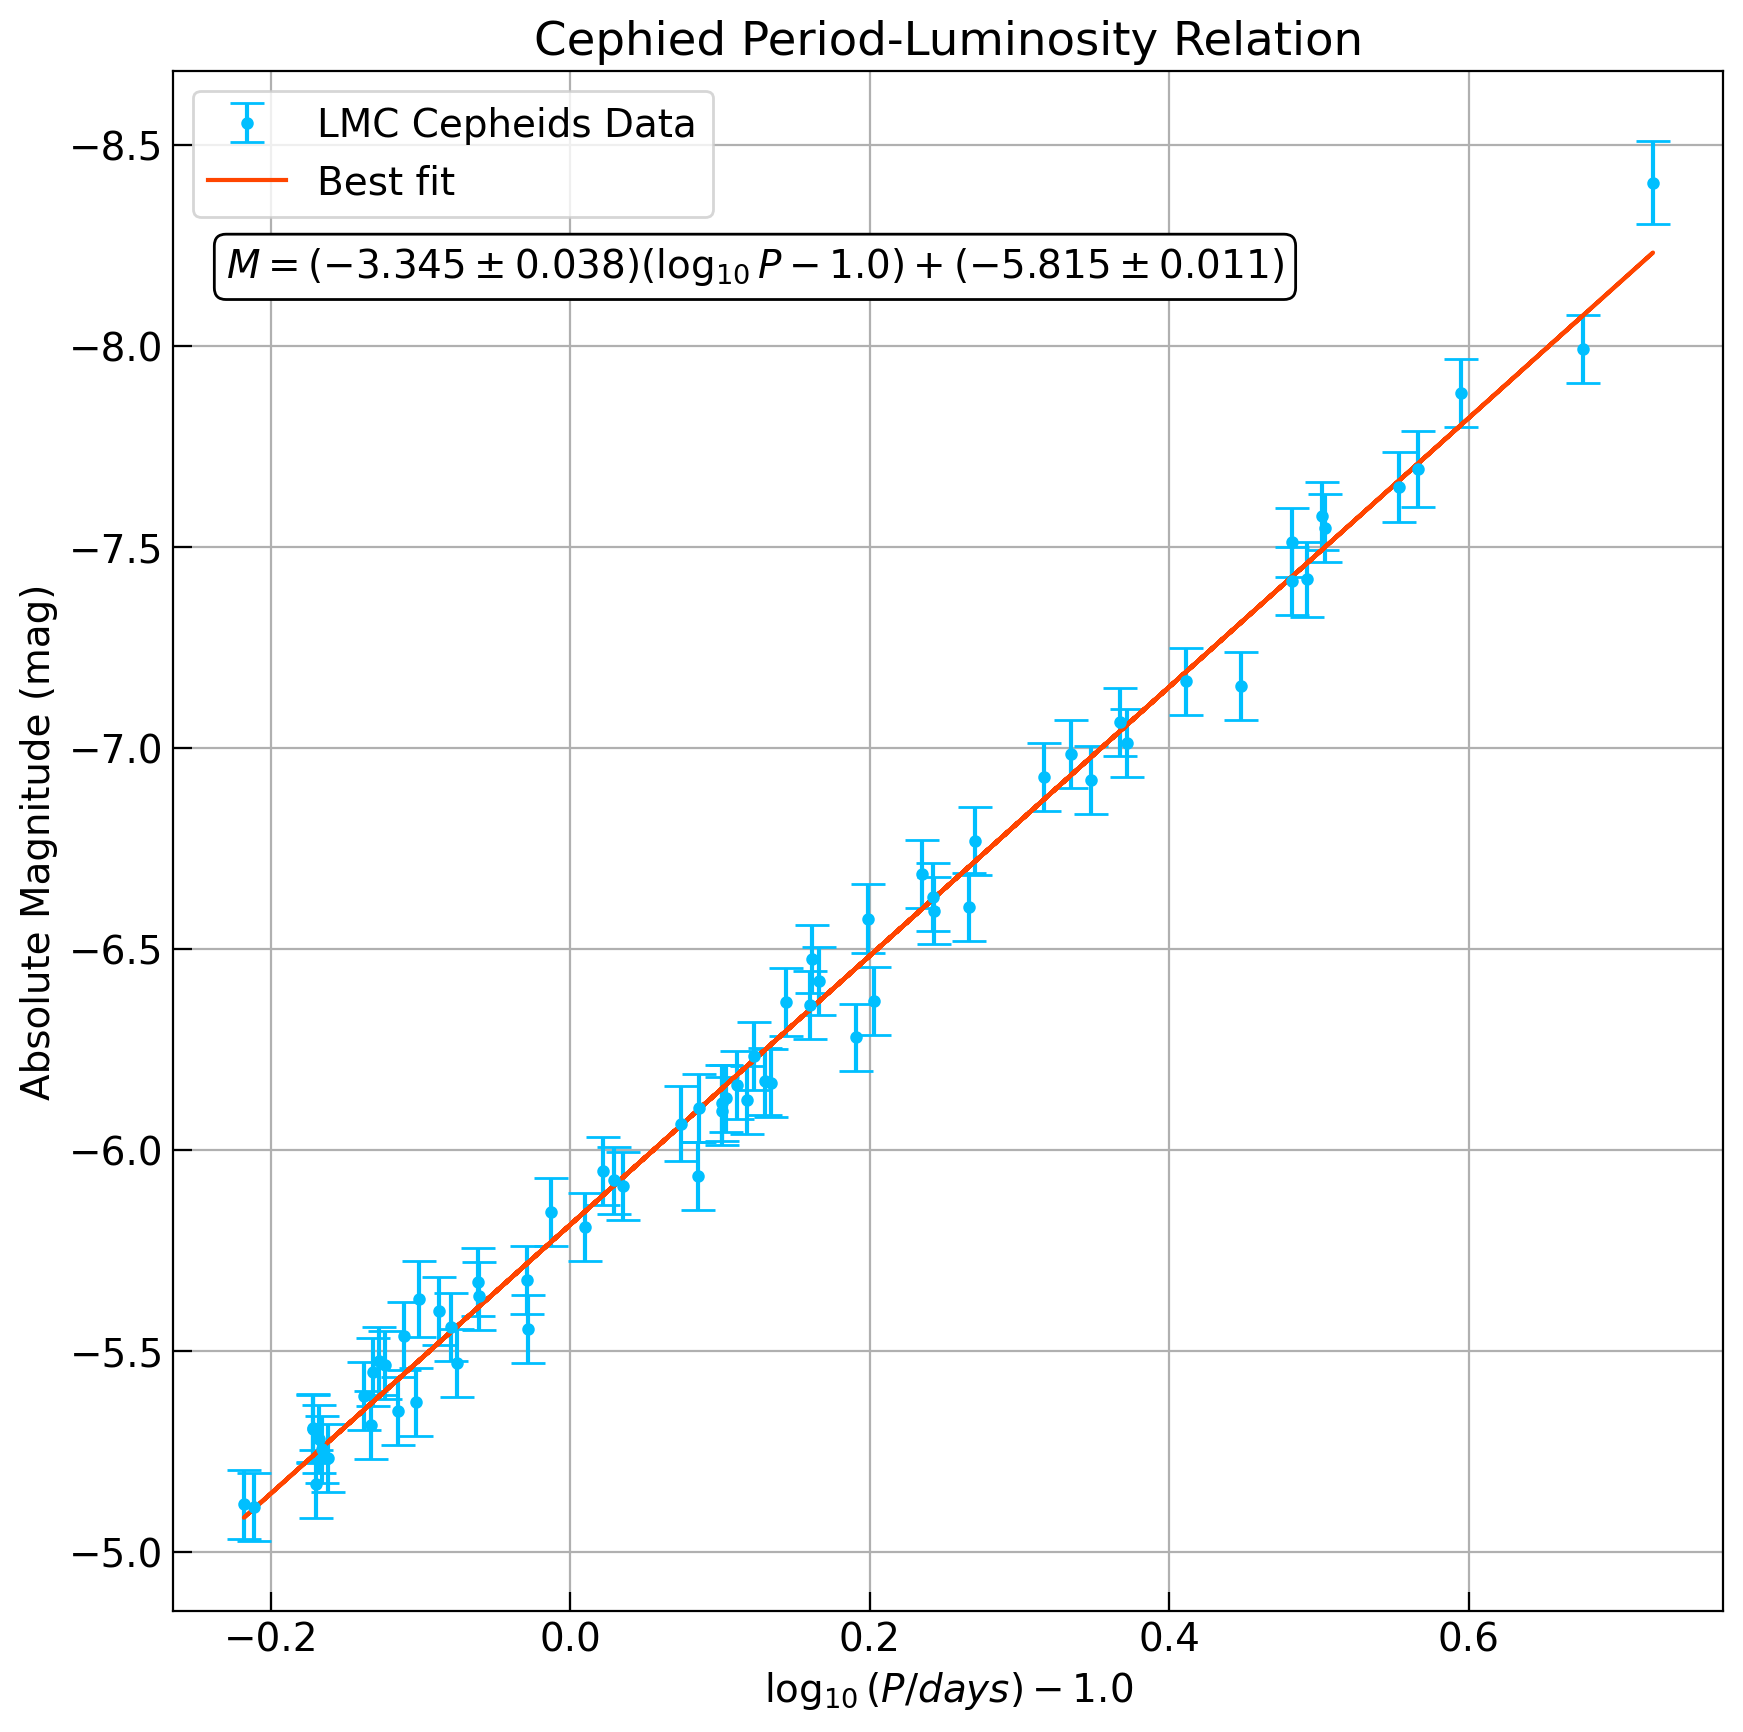

In [36]:
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(1,1,1)

ax.errorbar((np.log10(lmc_hst_df['P']) - 1.0),           
             lmc_hst_df['absolute_mag'],              
             yerr=lmc_hst_df['absolute_mag_unc'],     
             marker='.',             
             markersize = 7,        
             color='DeepSkyBlue',         
             ecolor='DeepSkyBlue',        
             markerfacecolor='DeepSkyBlue',
             linestyle='none',       
             capsize=6,  
             label = 'LMC Cepheids Data'
             )

ax.set_xlabel(r'$\log_{10}(P / days) - 1.0$')
ax.set_ylabel('Absolute Magnitude (mag)')

ax.tick_params(direction='in', length=7)

ax.plot((np.log10(lmc_hst_df['P']) - 1.0),
         a*(np.log10(lmc_hst_df['P']) - 1.0) + b, 
         linestyle='-',
         color='OrangeRed',
         label='Best fit')

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1],labels[::-1],loc=0, numpoints=1)
ax.set_title('Cephied Period-Luminosity Relation')


annotation = (f'$M = ({a:.3f} \\pm {err_a:.3f})' f'(\\log_{{10}}P - 1.0)' ' + '  f'({b:+.3f} \\pm {err_b:.3f})$')

ax.annotate(annotation,  xy=(-0.23, -8.25), xycoords='data', ha='left', va='top', bbox=dict(boxstyle='round', fc='w'))

ax.grid(True, which='major')
ax.invert_yaxis()


plt.show()

**Figure 1:** Plot of the period–luminosity relation for HST–observed Cepheid variables in the LMC. The data points show the absolute magnitudes (with uncertainties) plotted against $\log_{10}(P) - 1.0$. The solid line shows the best–fit linear relation $M = a(\log_{10}P - 1.0) + b$ using the fitted slope and intercept from the analysis.

### Absolute magnitude of a 10-day Cepheid

Finally, I use the fitted period–luminosity relation to calculate the absolute magnitude of a Cepheid with a period of 10 days, and propagate the uncertainties in the fitted parameters to estimate the uncertainty on this magnitude.

To calculate the uncertainty in the absolute magnitude of a 10-day Cepheid, with relationship:

$$
M = a(\log_{10}P - 1.0) + b
$$

For a fixed period, the only quantities with uncertainty are the fitted parameters \(a\) and \(b\).  

Writing

$$
x = \log_{10}P - 1.0
$$

the equation becomes

$$
M = ax + b
$$

The uncertainty in 'M' is then found using the standard result for a function depending on two independent variables:

$$
\sigma_M^2 = x^2\sigma_a^2 + \sigma_b^2
$$

where $\sigma_a^2$ and $\sigma_b^2$ come from the parameter uncertainties returned by the fit.  
Taking the square root gives the uncertainty '$\sigma_M$' in the predicted absolute magnitude for a 10-day Cepheid.




In [37]:
P_10 = 10.0

M_10 = period_luminosity_relation(P_10, a, b)

x_10 = np.log10(P_10) - 1.0

M_10_unc = np.sqrt((x_10**2) * pcov[0, 0] + pcov[1, 1])

print(f'Absolute magnitude for P = {P_10:.1f} days: M_10 = {M_10:.3f} ± {M_10_unc:.3f} mag')

Absolute magnitude for P = 10.0 days: M_10 = -5.815 ± 0.011 mag


The absolute magnitude of a 10-day Cepheid corresponds to the intercept of the fitted PL relation because at $P = 10 \text{ days}, \log{10}P - 1.0 = 0$.
Using the fitted values for $a$ and $b$:

$$
M_{10} = b \pm \sigma_b
$$

This value will be used in Part B when computing distance moduli for host galaxies that contain both Cepeids and Type Ia Supernovae.

## Part B: Find Supernova Ia $M_{abs}$ using galaxies with Cepheids and supernovae

The goal of Part B is to calibrate the absolute magnitude of Type Ia supernovae using galaxies in which both Cepheids and a Type Ia supernova have been observed. Since we already determined the absolute magnitude of a 10-day Cepheid in Part A, we can compute the distance modulus for each host galaxy and hence determine the absolute magnitude of the supernovae. This makes the second step of the distance ladder. This is done using data from 2 CSV files, one for host glaxies, and one for supernova observations, and then merging them.

- **`cep_host_galaxies.csv`** contains the host galaxy's named and photometric information for 10-day Cepheids.
- **`sn_observations.csv`** constains the galaxy's names, supernovae names, and the apparent magnitudes and the uncertainties in that value for the supernovae.

### Reading the data and merging the separate dataframes
Here I read in from `cep_host_galaxies.csv` and `sn_observations.csv`, then inner merge them on the `Galaxy` column to only keep rows where all of the data matches.

In [38]:
cep_hosts_df = pd.read_csv('./data/cep_host_galaxies.csv')
sn_obs_df = pd.read_csv('./data/sn_observations.csv')

cep_sn_df = pd.merge(cep_hosts_df, sn_obs_df, on='Galaxy', how='inner')

cep_sn_df.head()

,Galaxy,app_mag_10d,app_mag_10d_unc,SN,sn_app_mag,sn_app_mag_unc
0,M101,23.2722,0.0005,2011fe,9.780,0.115
1,M1337,27.0455,0.0218,2006D,13.655,0.106
2,N0691,26.9081,0.0063,2005W,13.602,0.139
3,N1015,26.7474,0.0051,2009ig,13.350,0.094
4,N1309,26.7299,0.0035,2002fk,13.209,0.082


Each row now contains the apparent magnitude of the galaxy’s 10-day Cepheid calibration and the apparent magnitude of the Type Ia supernova observed in the same host. This allows calculation of the galaxy's distance modulus, and thus the absolute magnitude of the supernova in that galaxy.

### Distance Modulus Function

The distance modulus given a fixed period can be calculated using: $\mu = m_{app} - M_{abs}$, where the period is 10 days. The absolute magnitude comes from the value calculated at the end of part A, $M_{10} = -5.815$, and the apparent magnitude comes from the column in `cep_sn_df` listed `app_mag_10d`. The uncertainty of the former also comes from part A, $M_{10,unc} = 0.011$, and for the latter comes from the column `app_mag_10d_unc`.

In [39]:
def modulus_appmag(m_app, M_abs):
    mod = m_app - M_abs
    return mod

### Adding Columns to the Dataframe

Using the calibrated 10-day Cepheid absolute magnitude ($M_{10}$) from part A, I calculate the distance modulus of each galaxy using: $\mu = m_{10d} - M_{10d}$.

In [40]:
cep_sn_df.loc[:, 'sn_distance_modulus'] = modulus_appmag(cep_sn_df['app_mag_10d'], M_10)
cep_sn_df.head()

,Galaxy,app_mag_10d,app_mag_10d_unc,SN,sn_app_mag,sn_app_mag_unc,sn_distance_modulus
0,M101,23.2722,0.0005,2011fe,9.780,0.115,29.086864
1,M1337,27.0455,0.0218,2006D,13.655,0.106,32.860164
2,N0691,26.9081,0.0063,2005W,13.602,0.139,32.722764
3,N1015,26.7474,0.0051,2009ig,13.350,0.094,32.562064
4,N1309,26.7299,0.0035,2002fk,13.209,0.082,32.544564


The equation is in the form $z=x+y$, therefore the `sig_z_unc` function can be used again. Here I append the uncertainty column to the dataframe.

In [41]:
cep_sn_df.loc[:, 'sn_distance_modulus_unc'] = sig_z_unc(cep_sn_df['app_mag_10d_unc'], M_10_unc)
cep_sn_df.head()

,Galaxy,app_mag_10d,app_mag_10d_unc,SN,sn_app_mag,sn_app_mag_unc,sn_distance_modulus,sn_distance_modulus_unc
0,M101,23.2722,0.0005,2011fe,9.780,0.115,29.086864,0.010578
1,M1337,27.0455,0.0218,2006D,13.655,0.106,32.860164,0.024226
2,N0691,26.9081,0.0063,2005W,13.602,0.139,32.722764,0.012302
3,N1015,26.7474,0.0051,2009ig,13.350,0.094,32.562064,0.011733
4,N1309,26.7299,0.0035,2002fk,13.209,0.082,32.544564,0.011131


Now, with the distance modulus of each supernova, I calculate the absolute magnitude using the apparent magnitude of the supernovae (`sn_app_mag`) and the respective distance modulus calculated above by using the `abs_mag_calc` function from part A. The absolute magnitude of each SN Ia is calculated by rearranging the distance modulus equation:

$$
M_{SN} = m_{SN} - \mu_{host}
$$

This converts the apparent magnitude of each supernova into its absolute magnitude. I also calculate the uncertainties, using the same method as before as this also takes the form $z=x+y$, and then add these values to the dataframe in two new columns.

In [42]:
cep_sn_df.loc[:, 'sn_abs_mag'] = abs_mag_calc(cep_sn_df['sn_app_mag'], cep_sn_df['sn_distance_modulus'])
cep_sn_df.loc[:, 'sn_abs_mag_unc'] = sig_z_unc(cep_sn_df['sn_app_mag_unc'], cep_sn_df['sn_distance_modulus_unc'])

cep_sn_df.head()

,Galaxy,app_mag_10d,app_mag_10d_unc,SN,sn_app_mag,sn_app_mag_unc,sn_distance_modulus,sn_distance_modulus_unc,sn_abs_mag,sn_abs_mag_unc
0,M101,23.2722,0.0005,2011fe,9.780,0.115,29.086864,0.010578,-19.306864,0.115485
1,M1337,27.0455,0.0218,2006D,13.655,0.106,32.860164,0.024226,-19.205164,0.108733
2,N0691,26.9081,0.0063,2005W,13.602,0.139,32.722764,0.012302,-19.120764,0.139543
3,N1015,26.7474,0.0051,2009ig,13.350,0.094,32.562064,0.011733,-19.212064,0.094729
4,N1309,26.7299,0.0035,2002fk,13.209,0.082,32.544564,0.011131,-19.335564,0.082752


### Histogram Plotting

I extract absolute magnitude of the supernovae into an array so that I can calculate the mean value and its uncertainty. I take the mean of the absolute magnitudes and calculate the uncertainty on it using the standard error of the sample ($\frac{\sigma}{\sqrt{N}}$). I then plot a histogram showing the distribution of the supernova absolute magnitudes, and annotate the plot with the calculated mean and its uncertainty.

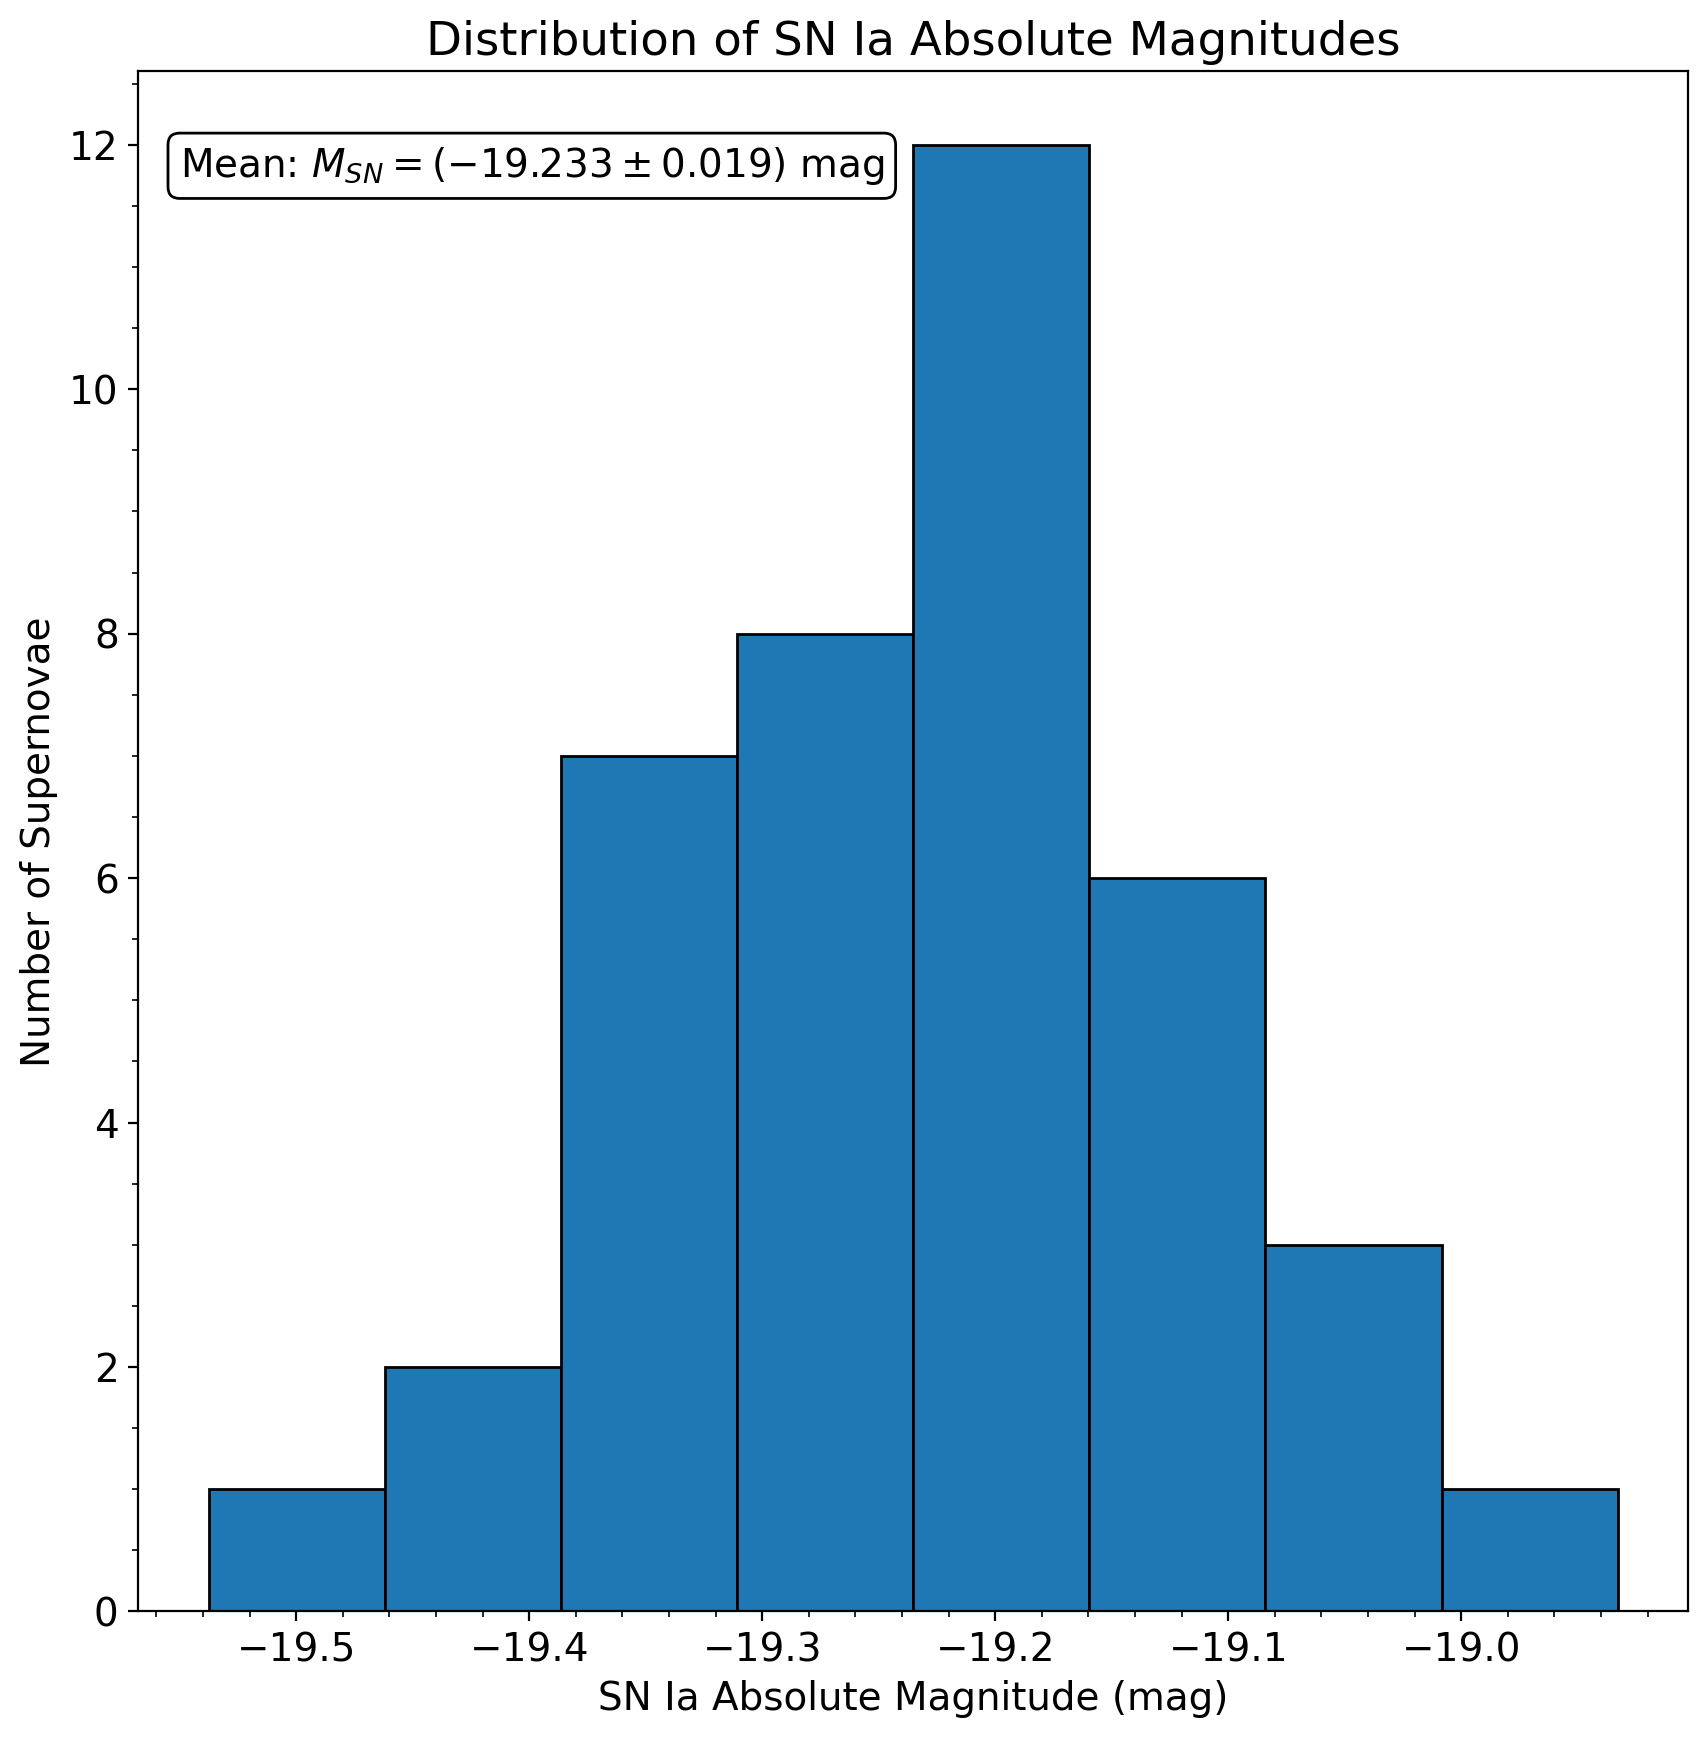

In [43]:
sn_abs_mag = cep_sn_df['sn_abs_mag'].astype(float).to_numpy()

sn_abs_mag_mean = sn_abs_mag.mean()
sn_abs_mag_mean_unc = sn_abs_mag.std(ddof=1) / np.sqrt(len(sn_abs_mag))

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(1,1,1)

ax.hist(cep_sn_df['sn_abs_mag'], bins='auto', edgecolor='black')
ax.set_xlabel("SN Ia Absolute Magnitude (mag)")
ax.set_ylabel('Number of Supernovae')
ax.set_title('Distribution of SN Ia Absolute Magnitudes')
ax.minorticks_on()

text = rf'Mean: $M_{{SN}} = ({sn_abs_mag_mean:.3f} \pm {sn_abs_mag_mean_unc:.3f})$ mag'
ax.annotate(text,  xy=(-19.55, 12), xycoords='data', ha='left', va='top', bbox=dict(boxstyle='round', fc='w'))

plt.show()

**Figure 2:** The historgram shows that the SN Ia absolute magnitudes have a lot of readings around the mean value. This narrow spread shows how useful Type Ia supernovae are as standard candles.

The mean absolute magnitude of the supernovae is: $M_{SN} = (-19.233 \pm 0.019) \text{ mag}$

## Part C: Use SN Ia distances and redshifts to calculate Hubble's Constant

In this part I am analysing data of supernovae across much larger distances as compared to the cep_host_galaxy.csv dataset. The data is contained in a single csv file:

- **`big_sn_sample.csv`** contains photometric data for supernovae, supernovae name, host galaxy's redshift, and the uncertainty of this redshift.

The aim of Part C is to use the SN Ia absolute magnitude from Part B to determine distances to a much larger supernova sample. By combining these distances with the redshifts, I will construct a Hubble diagram and fit for the Hubble constant $H_0$. At low redshifts, the expansion velocity is approximated by: $v \approx cz$. Combing this with Hubble's Law $v=H_0D$ allows us to determine $H_0$ from a linear fit of $z(D)$.

### Reading in the CSV File

I start by reading the csv file into a dataframe.

In [44]:
big_sn_df = pd.read_csv('./data/big_sn_sample.csv')
big_sn_df.head()

,SN_ID,redshift,redshift_unc,sn_app_mag,sn_app_mag_unc
0,2011fe,0.00122,0.00084,9.74571,1.516210
1,2011fe,0.00122,0.00084,9.80286,1.517230
2,2012cg,0.00256,0.00084,11.47030,0.781906
3,2012cg,0.00256,0.00084,11.49190,0.798612
4,1994DRichmond,0.00299,0.00084,11.52270,0.880798


### Calculating Distance Modulus and Uncertainties

Since Type Ia supernovae are trated as standard candles with mean absolute magnitude $M_{SN}$ (from Part B), I calculate the distance modulus for each object using:

$$
\mu = m_{SN} - M_{SN}
$$

I also propogate uncertainties using the previous method as the equation is of the form $z=x+y$.

In [45]:
big_sn_df.loc[:, 'distance_modulus'] = modulus_appmag(big_sn_df['sn_app_mag'], sn_abs_mag_mean)
big_sn_df.loc[:, 'distance_modulus_unc'] = sig_z_unc(big_sn_df['sn_app_mag_unc'], sn_abs_mag_mean_unc)

big_sn_df.head()

,SN_ID,redshift,redshift_unc,sn_app_mag,sn_app_mag_unc,distance_modulus,distance_modulus_unc
0,2011fe,0.00122,0.00084,9.74571,1.516210,28.978604,1.516325
1,2011fe,0.00122,0.00084,9.80286,1.517230,29.035754,1.517345
2,2012cg,0.00256,0.00084,11.47030,0.781906,30.703194,0.782129
3,2012cg,0.00256,0.00084,11.49190,0.798612,30.724794,0.798831
4,1994DRichmond,0.00299,0.00084,11.52270,0.880798,30.755594,0.880996


### Converting Distance Modulus to Megaparsecs

Equation (3) from the coursework instructions converts from parsecs to distance modulus, rearranging for distance gives:

$$
d = 10^{\frac{\mu+5}5} \text{ parsecs.}
$$

Convert to megaparsecs by dividing by $10^6$:

$$
d = \frac{10^{(\mu+5)/5}}{10^6} \text{ Mpc}
$$

In [46]:
def mod_to_parsec(mod):
 Mpc = 10**((mod + 5) / 5) / 1e6
 return Mpc

big_sn_df.loc[:, 'distance_Mpc'] = mod_to_parsec(big_sn_df['distance_modulus'])
big_sn_df.head()


,SN_ID,redshift,redshift_unc,sn_app_mag,sn_app_mag_unc,distance_modulus,distance_modulus_unc,distance_Mpc
0,2011fe,0.00122,0.00084,9.74571,1.516210,28.978604,1.516325,6.247708
1,2011fe,0.00122,0.00084,9.80286,1.517230,29.035754,1.517345,6.414322
2,2012cg,0.00256,0.00084,11.47030,0.781906,30.703194,0.782129,13.824159
3,2012cg,0.00256,0.00084,11.49190,0.798612,30.724794,0.798831,13.962357
4,1994DRichmond,0.00299,0.00084,11.52270,0.880798,30.755594,0.880996,14.161809


These distances are used to plot the Hubble diagram.

### Plotting Entire Supernovae Sample

I can now plot redshift against distance (Mpc).

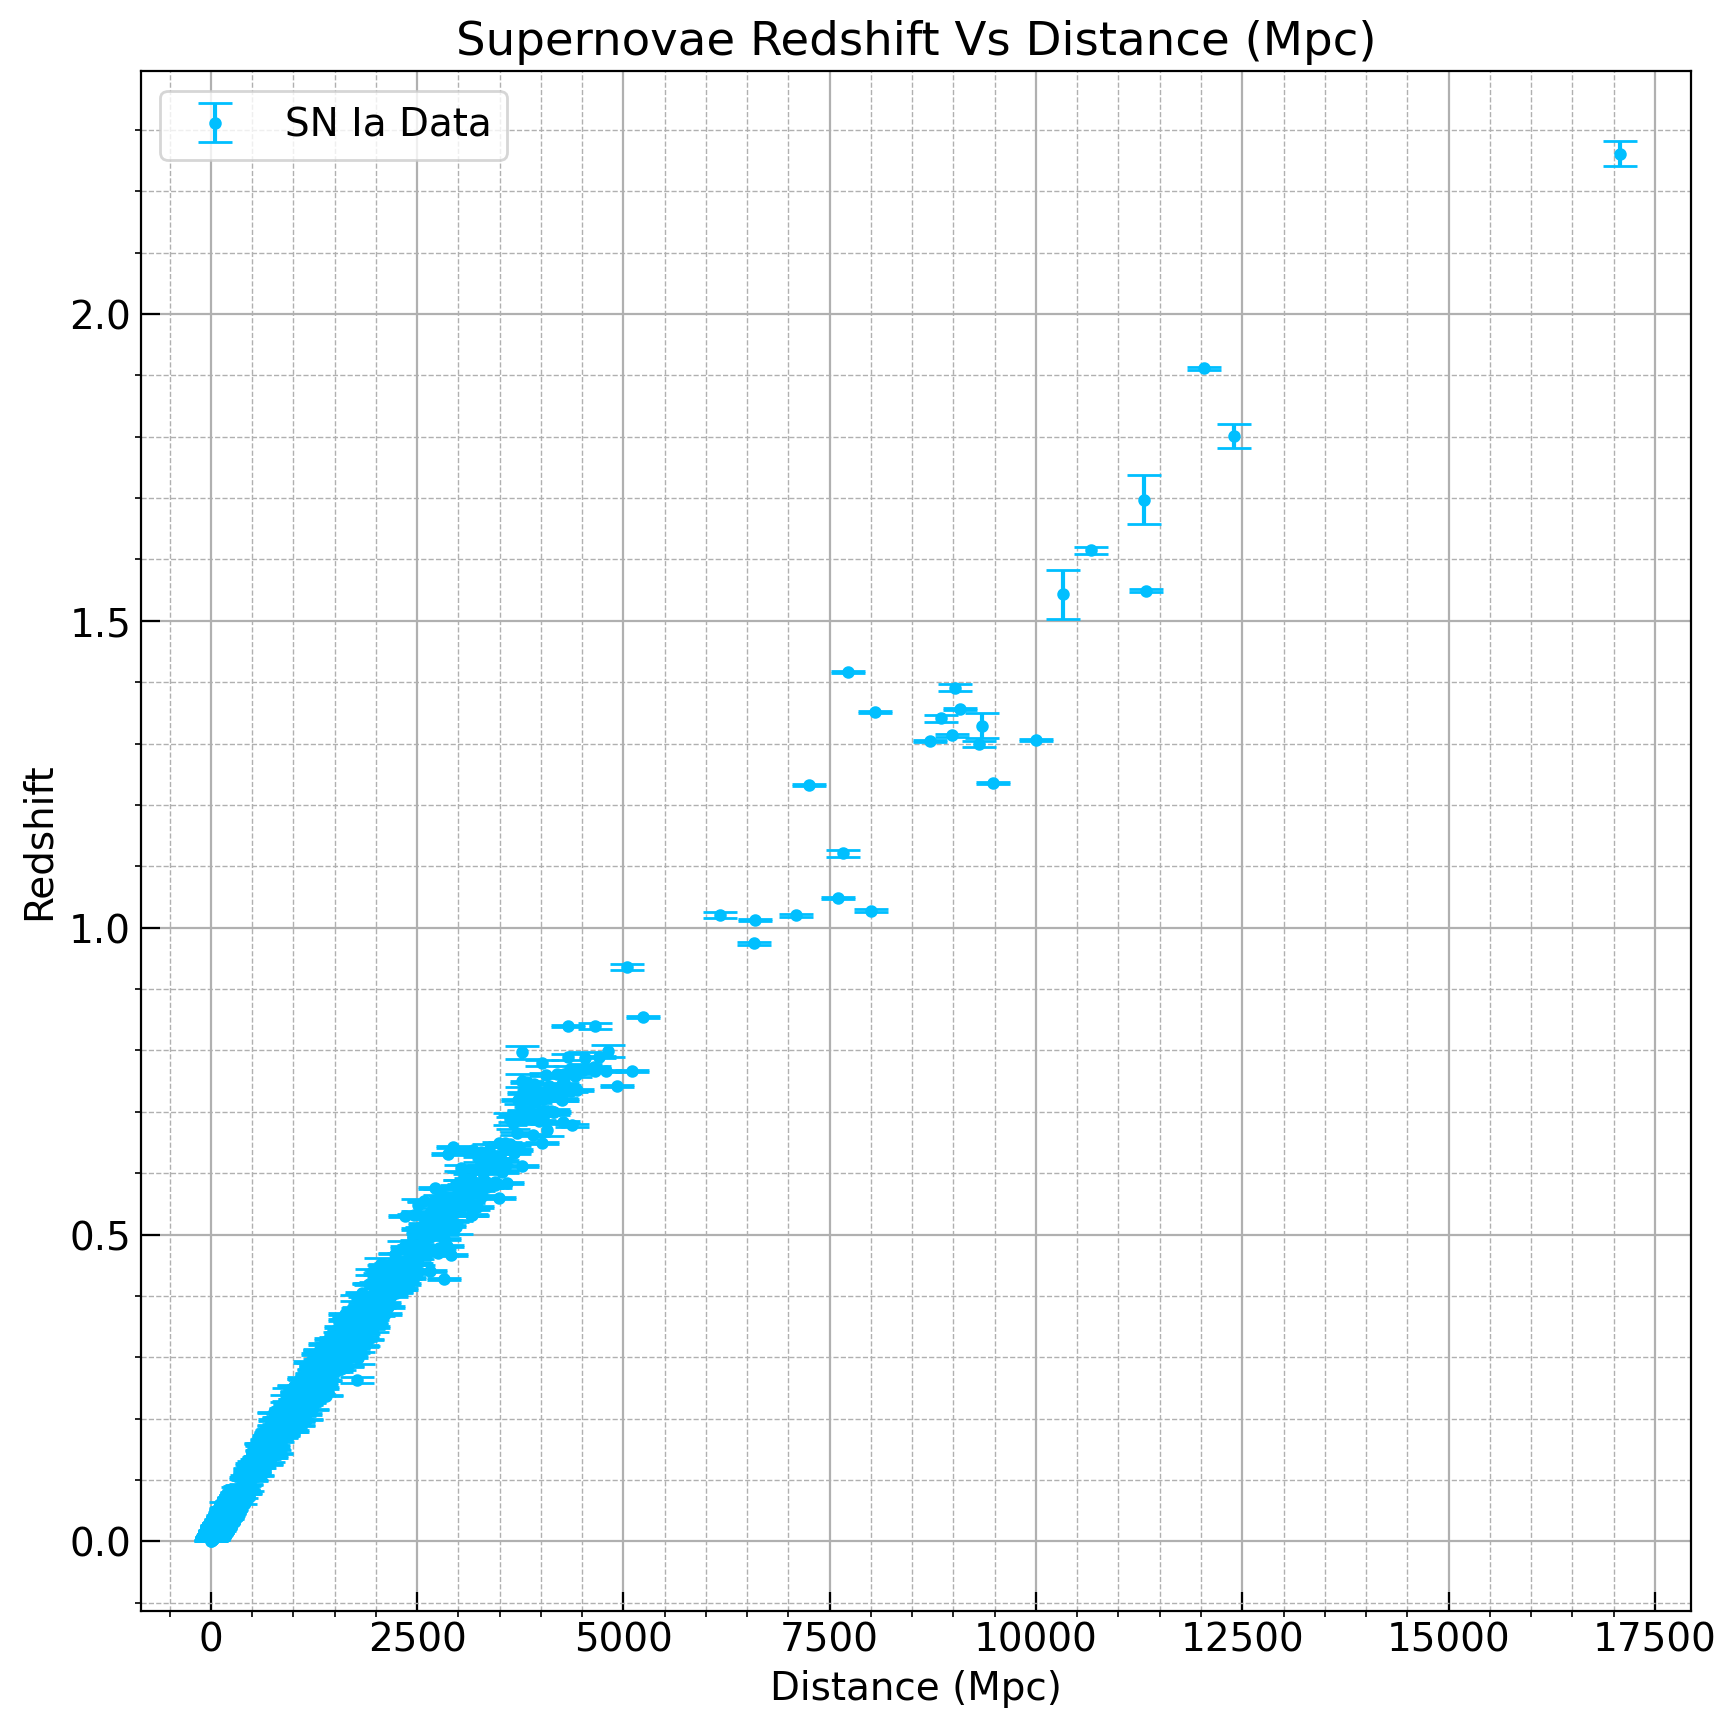

In [47]:
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(1,1,1)

ax.errorbar(
    big_sn_df['distance_Mpc'],        
    big_sn_df['redshift'],            
    yerr=big_sn_df['redshift_unc'],  
    marker='.',
    markersize=7,
    color='DeepSkyBlue',
    ecolor='DeepSkyBlue',
    markerfacecolor='DeepSkyBlue',
    linestyle='none',
    capsize=6,
    label='SN Ia Data'
)

ax.set_xlabel('Distance (Mpc)')
ax.set_ylabel('Redshift')
ax.set_title(f'Supernovae Redshift Vs Distance (Mpc)')


ax.tick_params(direction='in', length=7)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1], loc=0, numpoints=1)

ax.grid(True, which='major')
ax.minorticks_on()
ax.grid(True, which='minor', linestyle='--', linewidth=0.5)

plt.show()


**Figure 3:** The full sample of redshift against distance.
This reveals a clear increasing trend, but with curvature and scattering at larger distances. This is expected because $v=cz$ only holds accurate at low redshifts.

### d<400Mpc Dataframe

Here I create a new dataframe of supernovae with a distance less than 400Mpc, then show the maximum value of the `distance_Mpc` column in the new dataframe to check its less than 400Mpc.

In [48]:
sn_400mpc_df = big_sn_df.loc[big_sn_df['distance_Mpc'] < 400]
print(f'Furthest distance of supernova = {sn_400mpc_df['distance_Mpc'].max():.2f}')

Furthest distance of supernova = 399.35


The sample is restricted so that we only use the range where $v = cz$ holds accurate whilst still using a large enough sample.

### Hubble's Law Best Fit

Setting $v = H_0D$ and $v = cz$ equal to each other we get $H_0D = cz$. This can be rearranged as $z=\frac{H_0D}c$. This can then be used to find Hubble's constant as the gradient of the fit because the relationship is approximately linear.

In [49]:
c = 2.998*(10**5)

def hubble_law(D, H0):
    z = (H0 * D) / c
    return z

x = sn_400mpc_df['distance_Mpc']       
y = sn_400mpc_df['redshift']           
y_err = sn_400mpc_df['redshift_unc']   

popt, pcov = curve_fit(hubble_law, sn_400mpc_df['distance_Mpc'] , sn_400mpc_df['redshift'])

H0 = popt[0]
err_H0 = np.sqrt(pcov[0, 0])

print(f'H_0 = {H0:.2f} ± {err_H0:.2f} km s⁻¹ Mpc⁻¹')

H_0 = 70.56 ± 0.18 km s⁻¹ Mpc⁻¹


The best fit calculated that $H_0 = (70.56 \pm 0.18) \text{ km/sMpc}$

### Plotting Hubble's Law on d<400Mpc Supernovae Sample

I plot redshift against distance (Mpc), where the distance is less than 400Mpc. The best-fit value for $H_0$ is plotted on the graph with the corresponding line. The supernovae below 400Mpc lie close to the line which shows the linear approximation is suitable for this subset of the data.

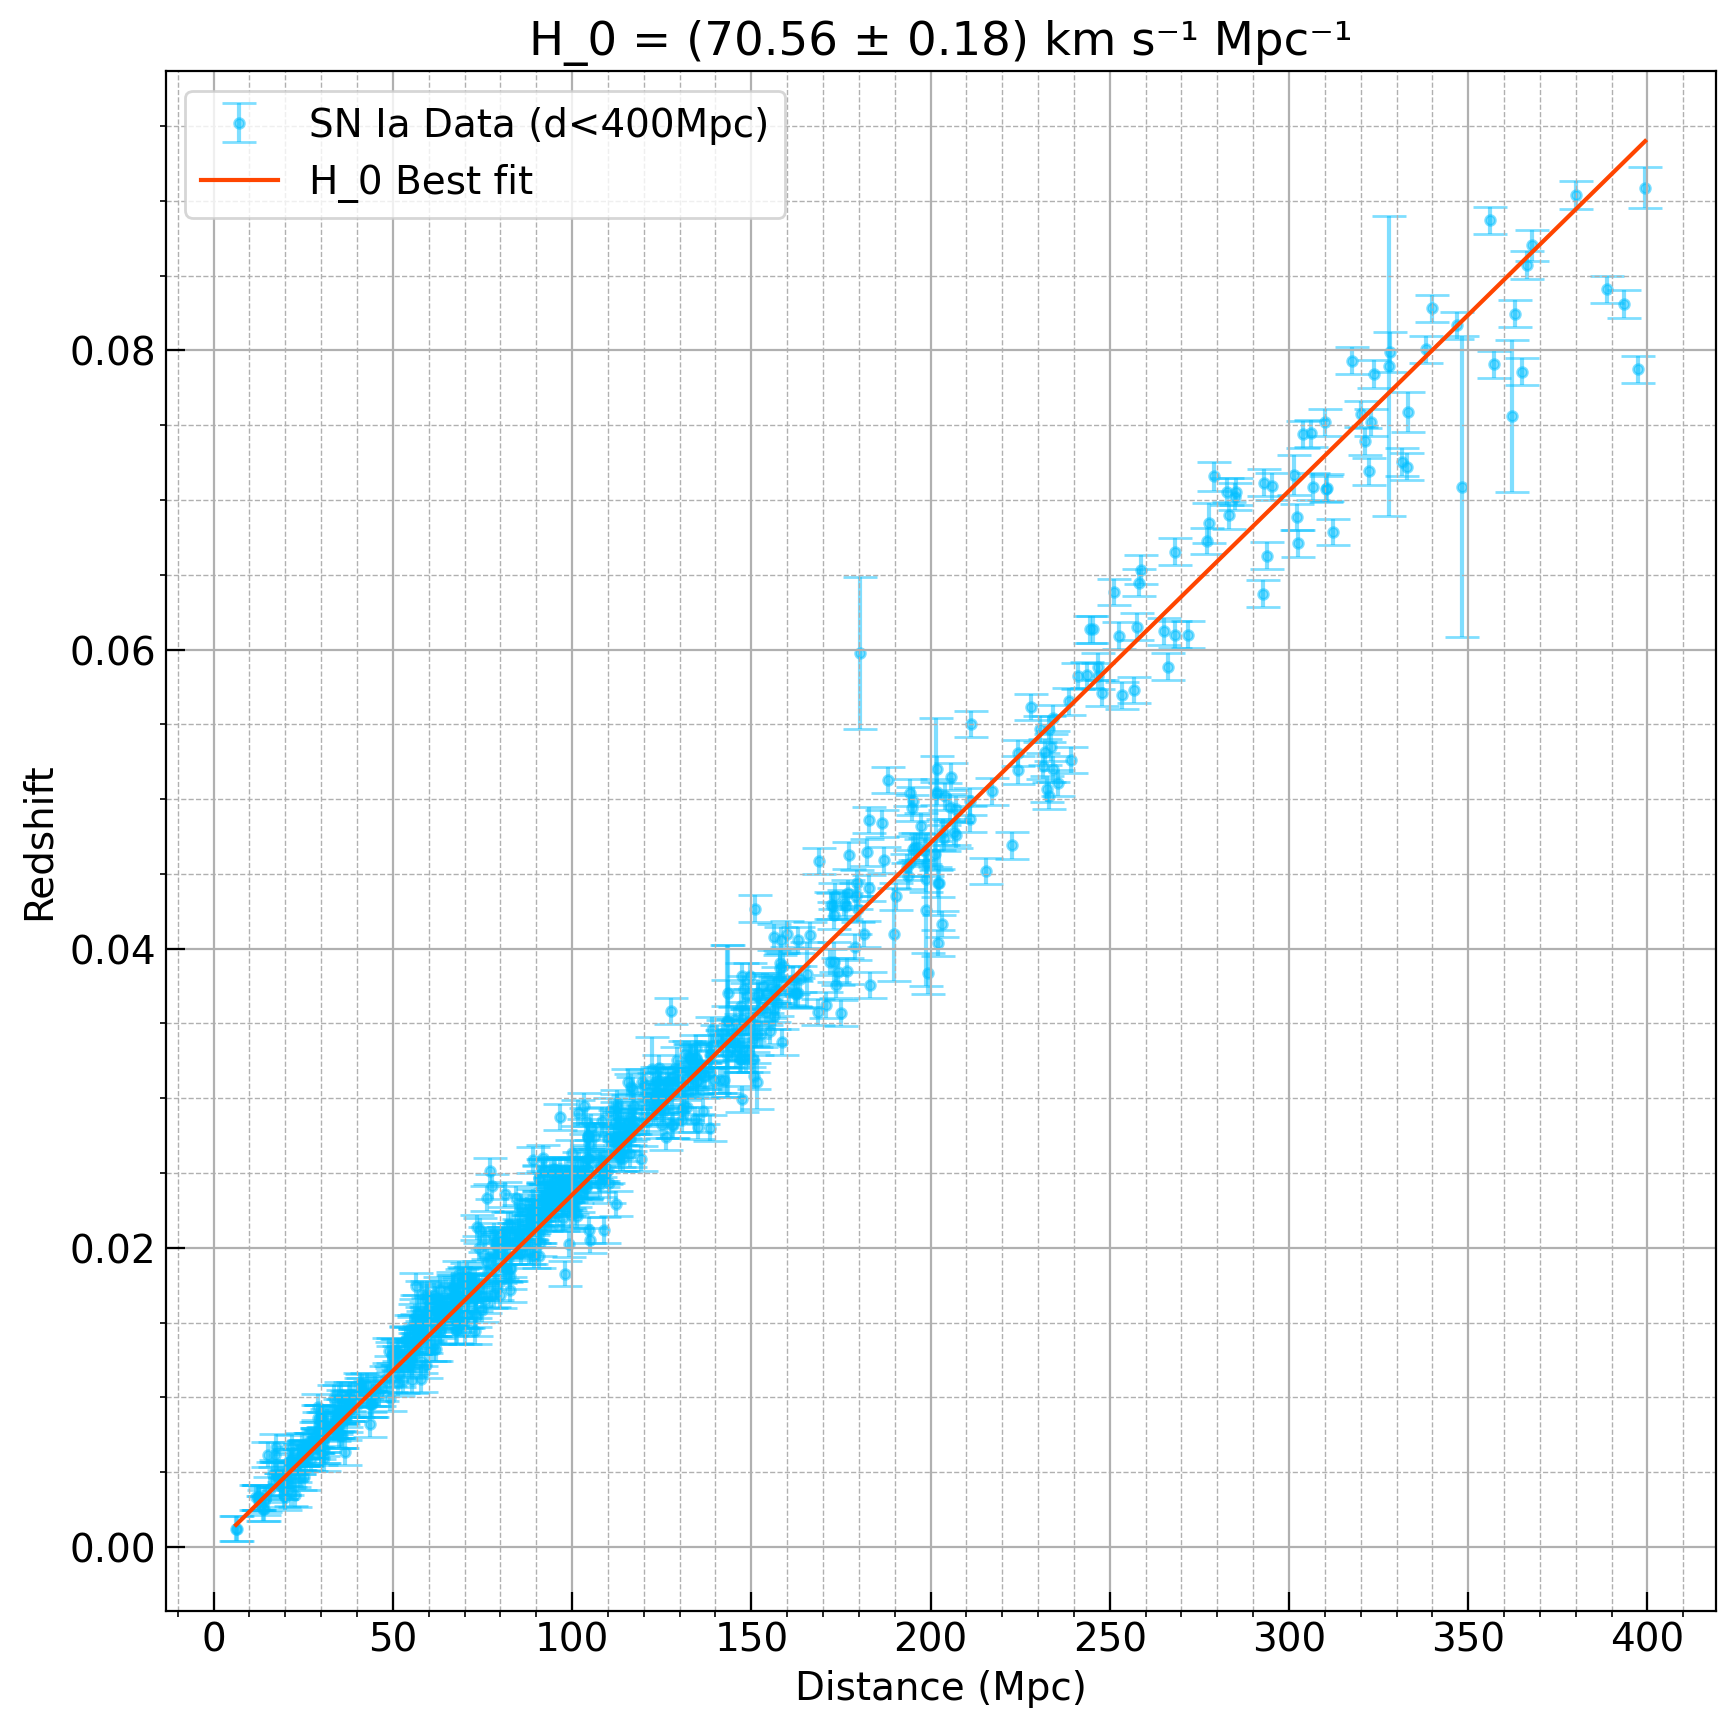

In [50]:
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(1,1,1)

ax.errorbar(
    sn_400mpc_df['distance_Mpc'],        
    sn_400mpc_df['redshift'],            
    yerr=sn_400mpc_df['redshift_unc'],  
    marker='.',
    markersize=7,
    color='DeepSkyBlue',
    ecolor='DeepSkyBlue',
    markerfacecolor='DeepSkyBlue',
    linestyle='none',
    capsize=6,
    label='SN Ia Data (d<400Mpc)',
    alpha = 0.5,
    zorder = 1
)

ax.set_xlabel('Distance (Mpc)')
ax.set_ylabel('Redshift')

ax.tick_params(direction='in', length=7)

ax.plot(sn_400mpc_df['distance_Mpc'],
         (H0 * sn_400mpc_df['distance_Mpc']) / c, 
         linestyle='-',
         color='OrangeRed',
         label='H_0 Best fit',
         alpha = 1,
         zorder = 3
         )

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1], loc=0, numpoints=1)
ax.set_title(f'H_0 = ({H0:.2f} ± {err_H0:.2f}) km s⁻¹ Mpc⁻¹')


ax.grid(True, which='major')
ax.minorticks_on()
ax.grid(True, which='minor', linestyle='--', linewidth=0.5)

plt.show()

**Figure 4:** The supernovae below 400 Mpc lie close to the line best fit line of Hubble's Law, indicating that the linear approximation is appropriate for this subset of the data.

### Hubble's Constant Comparison with Published Measurements

Using the supernova sample with distances below 400 Mpc, I obtain

$$
H_0 = 70.56 \pm 0.18  \text{ km/sMpc}.
$$

To compare this with the published measurements, I consider the Riess et al. (2022) value,

$$
H_0^{Riess} = 73.04 \pm 1.04,
$$

and the Planck Collaboration (2020) value,

$$
H_0^{Planck} = 67.4 \pm 0.5.
$$

My measurement lies between these results. The differences are

$$
\Delta_{Riess} = 2.48, \qquad
\Delta_{Planck} = 3.16,
$$

which correspond to

$$
N_{\sigma,Riess} \approx 2.37, \qquad
N_{\\sigma,Planck} \approx 6.16.
$$

These values show that my result is moderately inconsistent with the Riess measurement and strongly inconsistent with the Planck result. Because the uncertainty on my fitted value is small, even a few $kms^{-1}Mpc^{-1}$ difference leads to a significant discrepancy. Overall, the value obtained here lies between the late-Universe and early-Universe measurements, but agrees with neither within uncertainties.




### Plotting the Hubble–Law Comparison

To find out how well different measurements of the Hubble constant describe the full supernova sample, I plot the redshift of each supernova against its distance and overlay three model Hubble–law lines. These lines are my value of $H_0$ from the $D<400 Mpc$ subsample, the Riess et al. (2022) value, and the Planck Collaboration (2020) value. For each fit, the relationship between redshift and distance is given by the Hubble law

$$
z = \frac{H_0}cD
$$

so once a value of $H_0$ is specified, the predicted redshift is given by the distance. I first plot the full dataset with error bars, then make a common distance array for the full range of the supernovae sample and look at the redshifts for each chosen value of $H_0$. Plotting these three lines on the same axes allows me to compare how well each value reproduces the overall trend in the data.

The best-fit line obtained from the $D<400 Mpc$ subset provides the reference model extracted from my own analysis. The Riess and Planck lines show how two recent and widely used values of $H_0$ differ in their predicted redshift–distance relations. By visual comparison of these lines with the distribution of supernovae across the entire distance range, I can determind how well each value of $H_0$ shows the behaviour of the full dataset and see if my locally calibrated measurement is more consistent with either of the published results.

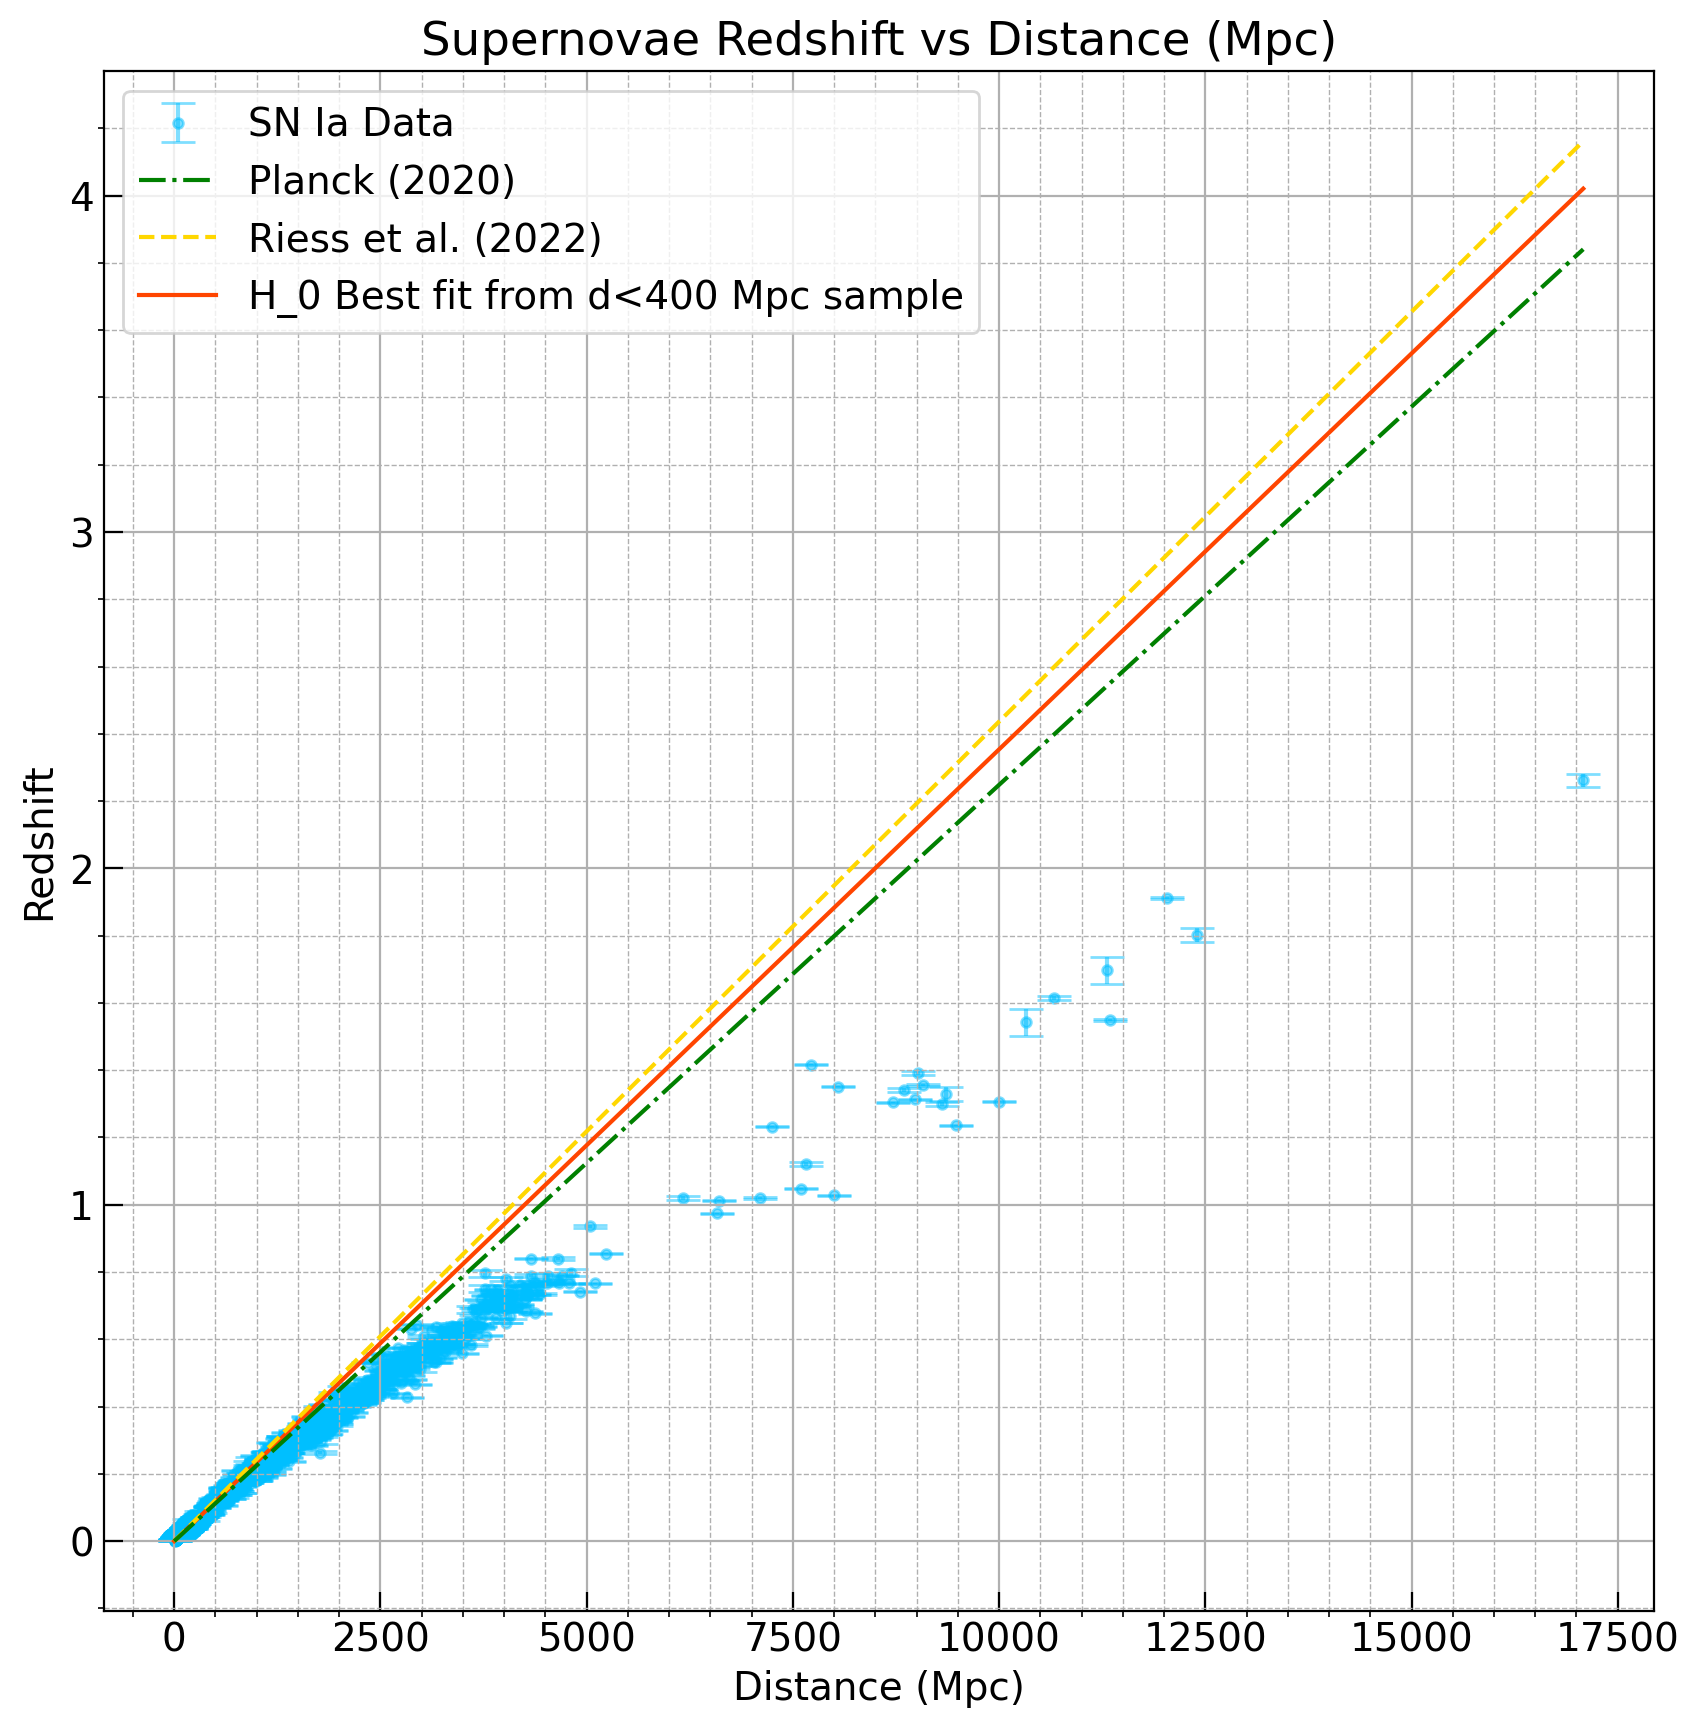

In [51]:
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(1, 1, 1)

ax.errorbar(
    big_sn_df['distance_Mpc'],
    big_sn_df['redshift'],
    yerr=big_sn_df['redshift_unc'],
    marker='.',
    markersize=7,
    color='DeepSkyBlue',
    ecolor='DeepSkyBlue',
    markerfacecolor='DeepSkyBlue',
    linestyle='none',
    capsize=6,
    label='SN Ia Data',
    alpha=0.5,
    zorder=1
)

ax.set_xlabel('Distance (Mpc)')
ax.set_ylabel('Redshift')
ax.set_title('Supernovae Redshift vs Distance (Mpc)')

ax.tick_params(direction='in', length=7)

x_line = np.linspace(0, big_sn_df['distance_Mpc'].max(), 1000)

y_fit = (H0 * x_line) / c
ax.plot(
    x_line, y_fit,
    linestyle='-',
    color='OrangeRed',
    label='H_0 Best fit from d<400 Mpc sample',
    alpha=1,
    zorder=3
)

H0_riess = 73.04
y_riess = (H0_riess * x_line) / c
ax.plot(
    x_line, y_riess,
    linestyle='--',
    color='Gold',
    label='Riess et al. (2022)',
    alpha=1,
    zorder=3
)

H0_planck = 67.4
y_planck = (H0_planck * x_line) / c
ax.plot(
    x_line, y_planck,
    linestyle='-.',
    color='Green',
    label='Planck (2020)',
    alpha=1,
    zorder=3
)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1], loc=0, numpoints=1)

ax.grid(True, which='major')
ax.minorticks_on()
ax.grid(True, which='minor', linestyle='--', linewidth=0.5)

plt.show()


**Figure 5:** Shows the different values for $H_0$ appear to overlap at smaller distances, but deviate as the distances increase. The linear approximation also becomes invalid for supernovae at larger distances due to the curvature in the dataset.

### Using a Different Sample to Calculate Hubble's Constant

To test the sensitivity of Hubble's constant based on the chosen distance, I chose the range of $400 \le D \le 4000$ then repeat the fit because it removes the nearby objects used in the original analysis, whilst staying in the approximately linear section of the graph which is what is relevant for Hubble's Law.

In [52]:
c = 2.998 * (10**5)  # km s^-1

def hubble_law_full(D, H0):
    z = (H0 * D) / c
    return z

mask_mid = (big_sn_df['distance_Mpc'] >= 400) & (big_sn_df['distance_Mpc'] <= 4000)
mid_sn_df = big_sn_df[mask_mid].copy()

x_mid = mid_sn_df['distance_Mpc']
y_mid = mid_sn_df['redshift']
y_err_mid = mid_sn_df['redshift_unc']

popt_mid, pcov_mid = curve_fit(hubble_law_full, x_mid, y_mid)
 
H0_mid = popt_mid[0]
err_H0_mid = np.sqrt(pcov_mid[0, 0])

print(f'H_0 (400–4000 Mpc) = {H0_mid:.2f} ± {err_H0_mid:.2f} km s⁻¹ Mpc⁻¹')


H_0 (400–4000 Mpc) = 57.69 ± 0.15 km s⁻¹ Mpc⁻¹


Using the range $400 \le D \le 4000$: $H_0 = (57.69 \pm 0.15) \text{ km/sMpc}$ which is vastly different from the previous value of $H_0 = 70.56 \pm 0.18  \text{ km/sMpc}$. This comparison shows that the value of the Hubble constant depends on which part of the distance ladder is used. Exploring different samples lets us analyse the validity of the measurement.

## Conclusion

I used Cepheid variables, Type Ia supernovae, and their host galaxies to measure the Hubble constant using the distance-ladder method.

Part A: Using HST observations of LMC Cepheids, I calibrated the period–luminosity relation and obtained the absolute magnitude of a 10-day Cepheid, $M_{10} = b \pm \sigma_b$.

Part B: Using galaxies that host both Cepheids and Type Ia supernovae, I determined the mean SN Ia absolute magnitude. The tight clustering of values confirms their usefulness as standard candles.

Part C: Using this calibration for a large supernova sample, I made a Hubble diagram and found a line of best fit for $H_0$. My measured value agrees more closely with Riess value, differing by only $N_{\sigma} = 2.37$ times. Repeating the fit with different distance selections shows that the inferred $H_0$ is sensitive to the chosen range, reflecting both measurement uncertainties and the issue with approximating $z = H_0D/c$ at higher redshift.

After analysing the data, I calculated Hubble's Constant to be: $H_0 = 70.56 \pm 0.18  \text{ km/sMpc}$. However, upon changing the range of distances included, the value changed to $H_0 = 57.69 \pm 0.15  \text{ km/sMpc}$ which demonstrates the previous point.

Overall, this analysis reproduces the key steps of the SH0ES distance-ladder method and highlights the sources of uncertainty that contribute to the current tension in modern measurements of the Hubble constant.